In [212]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import tensorflow as tf
from tensorflow.keras import layers, regularizers

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

In [213]:
DATA_PATH = Path("../data/processed/tickets_with_escalation_and_resolution.csv")

if not DATA_PATH.exists():
    DATA_PATH = Path("../data/processed/tickets_with_escalation.csv")

df = pd.read_csv(DATA_PATH)

print(df.shape)
print(df.columns.tolist())
df.head()

(8469, 31)
['ticket_id', 'customer_name', 'customer_email', 'customer_age', 'customer_gender', 'product_purchased', 'date_of_purchase', 'ticket_type', 'ticket_subject', 'ticket_description', 'ticket_status', 'resolution', 'ticket_priority', 'ticket_channel', 'first_response_time', 'time_to_resolution', 'customer_satisfaction_rating', 'ticket_text', 'text_length', 'word_count', 'has_urgent_keyword', 'has_payment_keyword', 'has_login_keyword', 'has_error_keyword', 'customer_tier', 'affected_users', 'previous_tickets_count', 'created_hour', 'escalation_probability_true', 'is_escalated', 'resolution_time_hours']


,ticket_id,customer_name,customer_email,customer_age,customer_gender,product_purchased,date_of_purchase,ticket_type,ticket_subject,ticket_description,...,has_payment_keyword,has_login_keyword,has_error_keyword,customer_tier,affected_users,previous_tickets_count,created_hour,escalation_probability_true,is_escalated,resolution_time_hours
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,...,1,0,1,standard,100,3,0,0.822229,1,19.111014
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,...,0,0,1,enterprise,10,2,14,0.740507,0,10.748864
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,...,1,0,0,premium,50,1,15,0.658627,1,16.053289
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,...,0,1,1,standard,1,7,9,0.517685,1,16.796999
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,...,0,0,1,free,5,1,19,0.364433,1,11.221525


In [214]:
required_cols = ["ticket_text", "is_escalated"]

missing = [col for col in required_cols if col not in df.columns]
missing

[]

In [215]:
df["ticket_text"] = df["ticket_text"].fillna("").astype(str)

df["ticket_text_clean"] = (
    df["ticket_text"]
    .str.lower()
    .str.replace(r"[^a-zA-Z0-9\s]", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

df = df[df["ticket_text_clean"].str.len() > 0].copy()

df["is_escalated"].value_counts(normalize=True) * 100

is_escalated
1    60.786397
0    39.213603
Name: proportion, dtype: float64

In [216]:
X = df["ticket_text_clean"]
y = df["is_escalated"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train_text.shape, X_test_text.shape

((6775,), (1694,))

In [217]:
tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=3
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

X_train_tfidf.shape, X_test_tfidf.shape

((6775, 4619), (1694, 4619))

In [218]:
svd = TruncatedSVD(
    n_components=200,
    random_state=RANDOM_STATE
)

X_train_svd = svd.fit_transform(X_train_tfidf)
X_test_svd = svd.transform(X_test_tfidf)

X_train_svd.shape, X_test_svd.shape

((6775, 200), (1694, 200))

In [219]:
scaler = StandardScaler()

X_train_final = scaler.fit_transform(X_train_svd)
X_test_final = scaler.transform(X_test_svd)

X_train_final.shape, X_test_final.shape

((6775, 200), (1694, 200))

In [220]:
model = tf.keras.Sequential([
    layers.Input(shape=(X_train_final.shape[1],)),

    layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    ),
    layers.Dropout(0.30),

    layers.Dense(
        32,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    ),
    layers.Dropout(0.20),

    layers.Dense(1, activation="sigmoid")
])

In [221]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,977 (58.50 KB)

 Trainable params: 14,977 (58.50 KB)

 Non-trainable params: 0 (0.00 B)

In [222]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_final,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.5489 - auc: 0.4984 - loss: 0.8906 - precision: 0.6062 - recall: 0.7279 - val_accuracy: 0.6052 - val_auc: 0.5225 - val_loss: 0.8011 - val_precision: 0.6177 - val_recall: 0.9450
Epoch 2/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5880 - auc: 0.5440 - loss: 0.8077 - precision: 0.6232 - recall: 0.8083 - val_accuracy: 0.6103 - val_auc: 0.5266 - val_loss: 0.7885 - val_precision: 0.6172 - val_recall: 0.9701
Epoch 3/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6129 - auc: 0.5961 - loss: 0.7726 - precision: 0.6316 - recall: 0.8656 - val_accuracy: 0.5993 - val_auc: 0.5330 - val_loss: 0.7790 - val_precision: 0.6130 - val_recall: 0.9510
Epoch 4/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6161 - auc: 0.6044 - loss: 0.7609 - precision: 0.6324 - recall: 0.8739 - val_accuracy: 0.6044 - val_auc: 0.5425 - val_loss: 0.7694 - val_precision: 0.6157 - val_recall: 0.9545
Epoch 5/50
170/170 ━━━━━━━━━━━━

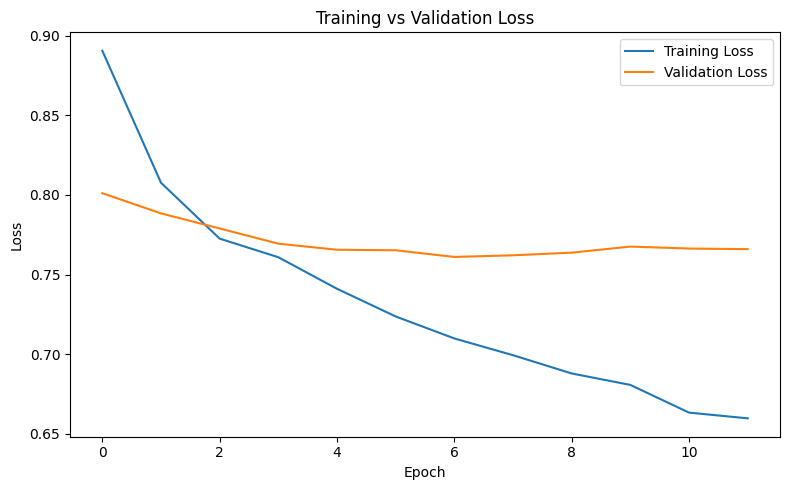

In [223]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

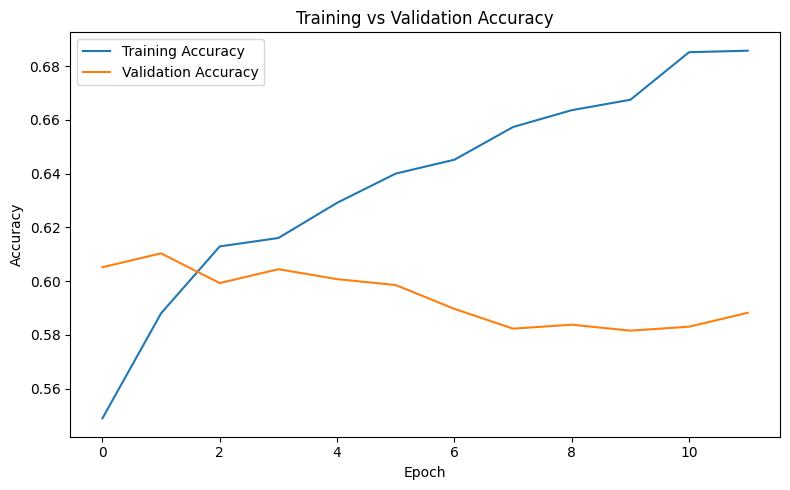

In [224]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

In [225]:
test_metrics = model.evaluate(X_test_final, y_test, verbose=0)

for name, value in zip(model.metrics_names, test_metrics):
    print(f"{name}: {value:.4f}")

loss: 0.7688
compile_metrics: 0.5939


In [226]:
y_proba = model.predict(X_test_final).ravel()
y_pred = (y_proba >= 0.5).astype(int)

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [227]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

print(classification_report(y_test, y_pred))

Accuracy: 0.5938606847697757
Precision: 0.6119109947643979
Recall: 0.9077669902912622
F1: 0.7310398749022674
ROC-AUC: 0.518284302257574
              precision    recall  f1-score   support

           0       0.43      0.11      0.17       664
           1       0.61      0.91      0.73      1030

    accuracy                           0.59      1694
   macro avg       0.52      0.51      0.45      1694
weighted avg       0.54      0.59      0.51      1694



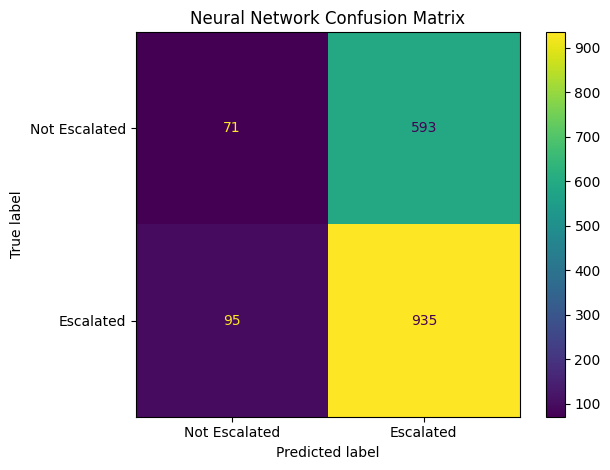

In [228]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Not Escalated", "Escalated"]
)

plt.title("Neural Network Confusion Matrix")
plt.tight_layout()
plt.show()

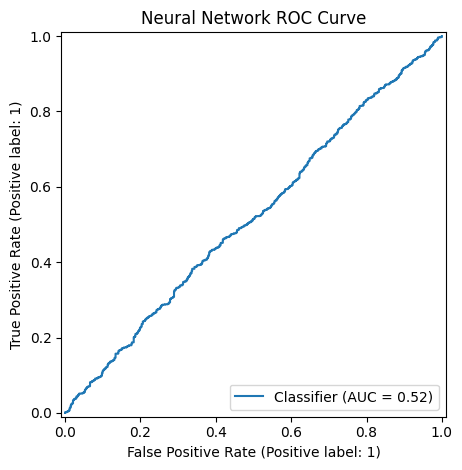

In [229]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("Neural Network ROC Curve")
plt.tight_layout()
plt.show()

In [230]:
model.save("../models/neural_escalation_keras_model.keras")

In [231]:
import joblib

joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")
joblib.dump(svd, "../models/svd_transformer.pkl")
joblib.dump(scaler, "../models/nn_scaler.pkl")

['../models/nn_scaler.pkl']

In [232]:
sample_text = ["payment failed and customer is blocked from completing invoice"]

sample_tfidf = tfidf.transform(sample_text)
sample_svd = svd.transform(sample_tfidf)
sample_final = scaler.transform(sample_svd)

probability = model.predict(sample_final).ravel()[0]

probability

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


np.float32(0.72386336)